# 06 - Experimento 4 (BONUS): Sensibilidad geométrica

Este experimento NO está en `deber03.pdf` original; lo agregamos como complemento.

**Pregunta**: ¿cómo cambia la solución (centro, radio, arista activa) cuando
activamos diferentes subconjuntos de las 6 zonas prohibidas?

**Niveles de restricción evaluados**:
1. **Sin restricciones (libre)** — solo cobertura, sin geometría.
2. **Solo Central Park** — la zona que atrapa al centro libre.
3. **CP + barrera norte** — Central Park + Morningside + Marcus Garvey.
4. **Las 6 zonas** — escenario completo de la Fase 3.

Esto sirve para entender qué restricciones son realmente *vinculantes* en el óptimo y cuáles son redundantes.

In [1]:
import sys
sys.path.insert(0, '..')
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon as MplPolygon

from src.preprocessing import cargar_procesado, obtener_puntos
from src.data_loader import obtener_zonas_osm
from src.constraints import cargar_zonas_utm, descomponer_zonas
from src.seb_seidel import seb_seidel
from src.seb_restringido import seb_restringido

In [2]:
df = cargar_procesado()
puntos = obtener_puntos(df)
zonas_wgs = obtener_zonas_osm()
zonas_utm = cargar_zonas_utm(zonas_wgs)
R, prohibidas = descomponer_zonas(zonas_utm, 'region_factible')
zonas_dict = dict(prohibidas)
print(f'n = {len(puntos):,} puntos')
print(f'Zonas disponibles: {list(zonas_dict.keys())}')

[cache] Cargando zonas desde zonas_prohibidas.geojson
n = 7,947 puntos
Zonas disponibles: ['central_park', 'morningside_park', 'marcus_garvey_park', 'inwood_hill_park', 'fort_tryon_park', 'battery_park']


## 1. Definir niveles de restricción

In [3]:
niveles = [
    ('libre', []),
    ('solo_central_park', ['central_park']),
    ('barrera_norte', ['central_park', 'morningside_park', 'marcus_garvey_park']),
    ('seis_zonas', list(zonas_dict.keys())),
]
for nombre, lista in niveles:
    print(f'  {nombre:>22}: {len(lista)} zona(s) -> {lista}')

                   libre: 0 zona(s) -> []
       solo_central_park: 1 zona(s) -> ['central_park']
           barrera_norte: 3 zona(s) -> ['central_park', 'morningside_park', 'marcus_garvey_park']
              seis_zonas: 6 zona(s) -> ['central_park', 'morningside_park', 'marcus_garvey_park', 'inwood_hill_park', 'fort_tryon_park', 'battery_park']


## 2. Resolver cada nivel

In [4]:
# SEB libre como referencia
c_libre, r_libre = seb_seidel(puntos, semilla=42)
print(f'SEB libre (referencia): r = {r_libre/1000:.4f} km, centro = ({c_libre[0]:.1f}, {c_libre[1]:.1f})')

filas = []
resultados = {}
for nombre, nombres_zonas in niveles:
    if not nombres_zonas:
        # nivel 'libre'
        radio = r_libre
        centro = c_libre
        estado = 'libre'
        arista = '-'
        t = 0.0
        n_eval = 0
    else:
        zonas_lvl = [(n, zonas_dict[n]) for n in nombres_zonas]
        t0 = time.perf_counter()
        res = seb_restringido(puntos, R, zonas_lvl, semilla=42)
        t = time.perf_counter() - t0
        radio = res['radio']
        centro = res['centro']
        estado = res['estado']
        n_eval = res['n_candidatos_evaluados']
        if res['arista_activa']:
            a = res['arista_activa']
            arista = f'{a["fuente"]}#{a["arista_idx"]}'
        else:
            arista = '-'
        resultados[nombre] = res
    delta_r = radio - r_libre
    delta_c = float(np.linalg.norm(centro - c_libre)) if centro is not None else float('nan')
    filas.append({
        'nivel': nombre,
        '# zonas': len(nombres_zonas),
        'estado': estado,
        'radio_km': radio/1000 if np.isfinite(radio) else np.nan,
        'delta_r_m': delta_r if np.isfinite(delta_r) else np.nan,
        'delta_c_m': delta_c,
        'arista_activa': arista,
        'aristas_eval': n_eval,
        'tiempo_ms': t*1000,
    })
    radio_str = 'inf' if not np.isfinite(radio) else f'{radio/1000:.4f} km'
    print(f'  {nombre:>22}: estado={estado:<12} r={radio_str:>14}  dr={delta_r:>+8.2f} m  '
          f'dc={delta_c:>7.1f} m  arista={arista}')

df_s = pd.DataFrame(filas)
df_s

SEB libre (referencia): r = 10.4244 km, centro = (587435.8, 4515612.9)
                   libre: estado=libre        r=    10.4244 km  dr=   +0.00 m  dc=    0.0 m  arista=-


       solo_central_park: estado=restringido  r=    10.4293 km  dr=   +4.93 m  dc=  320.5 m  arista=central_park#24


           barrera_norte: estado=restringido  r=    10.4293 km  dr=   +4.93 m  dc=  320.5 m  arista=central_park#24


              seis_zonas: estado=restringido  r=    10.4293 km  dr=   +4.93 m  dc=  320.5 m  arista=central_park#24


,nivel,# zonas,estado,radio_km,delta_r_m,delta_c_m,arista_activa,aristas_eval,tiempo_ms
0,libre,0,libre,10.424376,0.000000,0.000000,-,0,0.0000
1,solo_central_park,1,restringido,10.429301,4.925111,320.478742,central_park#24,108,316.7443
2,barrera_norte,3,restringido,10.429301,4.925111,320.478742,central_park#24,175,495.3919
3,seis_zonas,6,restringido,10.429301,4.925111,320.478742,central_park#24,260,579.1660


## 3. Visualización: 4 paneles, uno por nivel

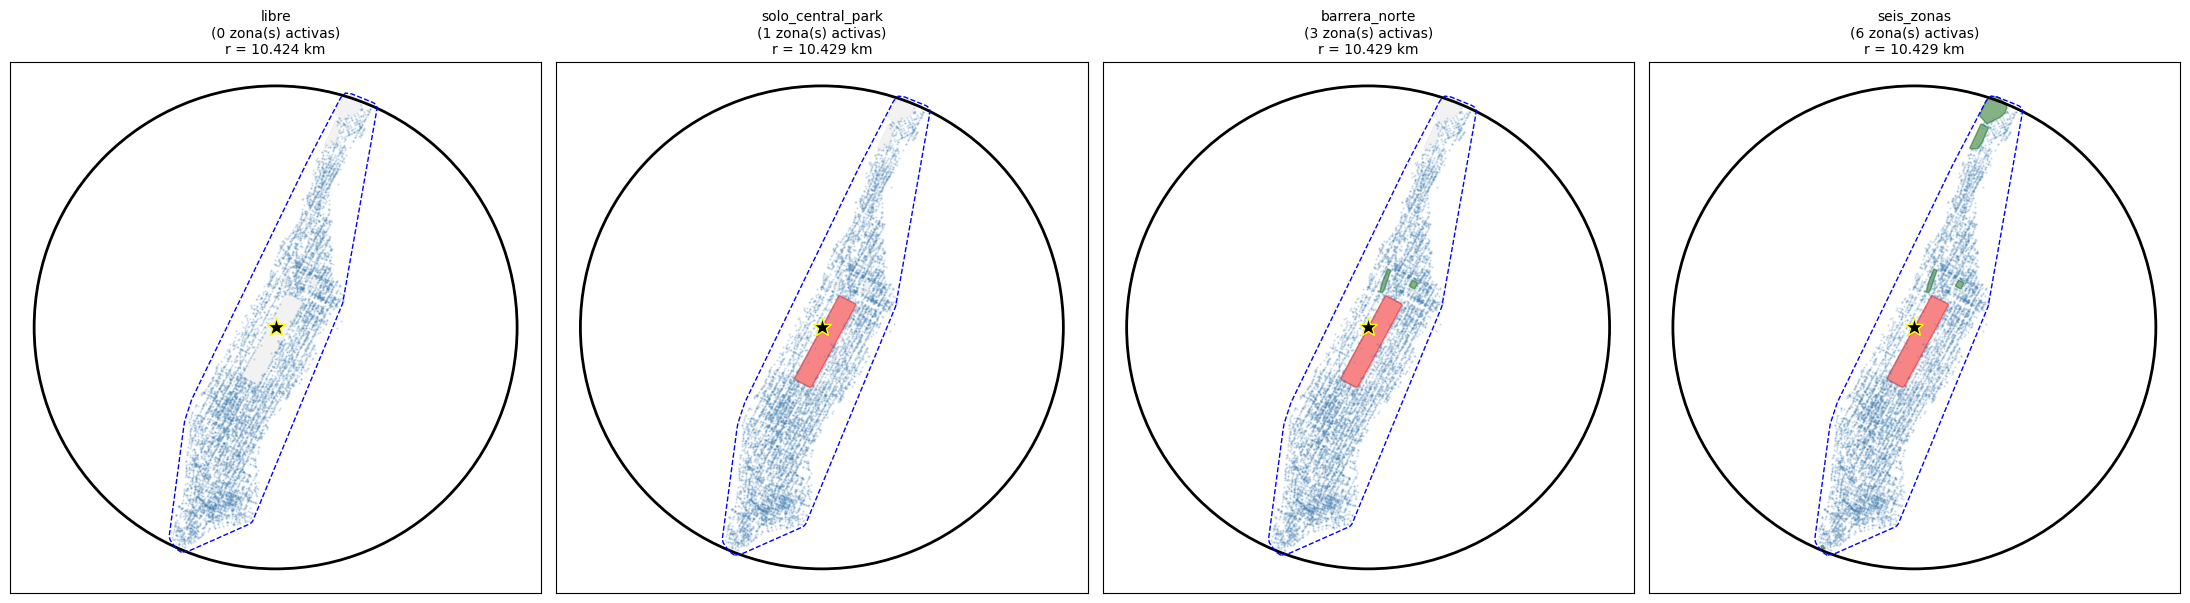

In [5]:
fig, axs = plt.subplots(1, 4, figsize=(22, 7))
for ax, (nombre, nombres_zonas) in zip(axs, niveles):
    # R
    xs, ys = R.exterior.coords.xy
    ax.plot(xs, ys, 'b--', linewidth=1)

    # Todas las zonas con bajo alpha (referencia)
    for n, p in prohibidas:
        xs, ys = p.exterior.coords.xy
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor='gray',
                                alpha=0.10, edgecolor='gray', linewidth=0.5))

    # Zonas activas en este nivel
    for nz in nombres_zonas:
        p = zonas_dict[nz]
        xs, ys = p.exterior.coords.xy
        color = 'red' if nz == 'central_park' else 'darkgreen'
        ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor=color,
                                alpha=0.45, edgecolor=color, linewidth=1))

    # Puntos
    ax.scatter(puntos[:, 0], puntos[:, 1], s=0.5, alpha=0.2, color='steelblue')

    # Centro y circulo
    if nombre == 'libre':
        c, r = c_libre, r_libre
    else:
        c, r = resultados[nombre]['centro'], resultados[nombre]['radio']
    if c is not None:
        ax.add_patch(Circle(c, r, fill=False, edgecolor='black', linewidth=2))
        ax.plot(c[0], c[1], 'k*', markersize=14, markeredgecolor='yellow')

    ax.set_aspect('equal')
    ax.set_xticks([]); ax.set_yticks([])
    titulo = f'{nombre}\n({len(nombres_zonas)} zona(s) activas)'
    if c is not None:
        titulo += f'\nr = {r/1000:.3f} km'
    ax.set_title(titulo, fontsize=10)

plt.tight_layout()
plt.savefig('../results/figures/06_sensibilidad_niveles.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Trayectoria del centro (zoom alrededor de Central Park)

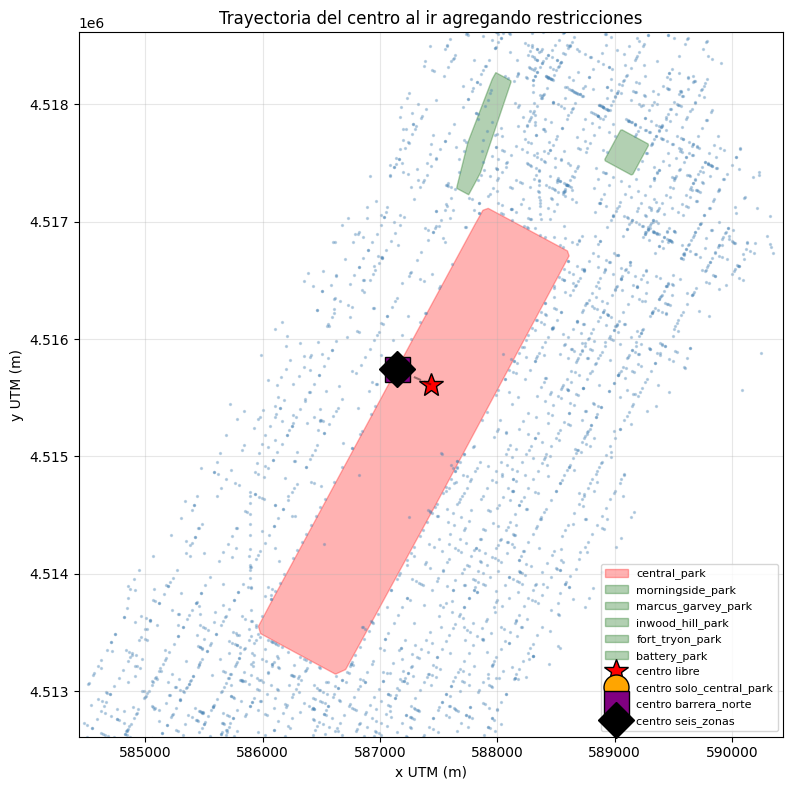

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

# Zonas como referencia
for n, p in prohibidas:
    xs, ys = p.exterior.coords.xy
    color = 'red' if n == 'central_park' else 'darkgreen'
    ax.add_patch(MplPolygon(list(zip(xs, ys)), facecolor=color,
                            alpha=0.30, edgecolor=color, linewidth=1, label=n))

# Puntos
ax.scatter(puntos[:, 0], puntos[:, 1], s=2, alpha=0.3, color='steelblue')

# Centros para todos los niveles
marcadores = ['*', 'o', 's', 'D']
colores_lvl = ['red', 'orange', 'purple', 'black']
centros = []
for (nombre, _), m, col in zip(niveles, marcadores, colores_lvl):
    if nombre == 'libre':
        c = c_libre
    else:
        c = resultados[nombre]['centro']
    if c is not None:
        ax.plot(c[0], c[1], marker=m, markersize=18, color=col,
                markeredgecolor='black', label=f'centro {nombre}', linestyle='None')
        centros.append(c)

# Linea conectando los centros
if len(centros) >= 2:
    cs = np.array(centros)
    ax.plot(cs[:, 0], cs[:, 1], 'k--', alpha=0.4, linewidth=1.5)

x0, y0 = c_libre
ax.set_xlim(x0 - 3000, x0 + 3000)
ax.set_ylim(y0 - 3000, y0 + 3000)
ax.set_aspect('equal')
ax.set_xlabel('x UTM (m)')
ax.set_ylabel('y UTM (m)')
ax.set_title('Trayectoria del centro al ir agregando restricciones')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/figures/06_trayectoria_centro.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Conclusiones

- Solo **Central Park** es la restricción vinculante en el óptimo final.
  Agregar Morningside + Marcus Garvey (barrera norte) **no cambia el centro
  ni el radio**: el algoritmo prefiere salir hacia el sur, no hacia el norte.
- Las 3 zonas adicionales (Inwood Hill, Fort Tryon, Battery) son
  **redundantes en este dataset**: están geográficamente lejos del centro
  óptimo y nunca activan.
- Esto valida geométricamente el resultado de Fase 3: el desplazamiento de
  320 m hacia el suroeste depende exclusivamente de Central Park.